# Task 4: Neural Visual Search


## 1. Introduction

This notebook tackles **Task 4: Neural Visual Search** for Assignment 2. The objective is to find fashion products that are visually similar to a query image. The article-type CNN chosen in Task 1 is reused as an image encoder. We remove its final classification layer, and use the resulting 256 dimensional hidden representation as the embedding for each image. In this task no further training of neural networks is done.

The visual-search procedure is as follows:

- **Feature extraction:** We convert each RGB product image into an embedding using the selected article-type CNN.
- **L2 normalization:** Normalize each embedding to have a length of one, so that comparisons depend on the direction of the vector and not its magnitude.
- **Cosine-similarity ranking**: Generate an embedding for a query, calculate the similarity with the training-gallery embeddings and output the closest products.
- **Qualitative inspection:** Show representative queries and their retrieved neighbors to inspect visual successes and failures.

Evaluation of retrieval performance is performed through:

- **Precision@1 and Precision@5:** The proportion of the top 1 or top 5 returned products that satisfy the relevance criteria.
- **Hit@5:** Whether at least one relevant product appears in the first five results.
- **Recall@10:** The percentage of all relevant gallery products retrieved among the top ten results.
- **Mean Reciprocal Rank (MRR)**: The rank of the first relevant product in the ranked list.

Two definitions of relevance are explored. **Article-type relevance** is when the item is considered relevant if it has the same article-type label as the query. **Joint article-and-colour relevance** also requires the same base-colour label and is therefore more demanding. Since the encoder was trained for article type classification and not metric learning or color recognition, it is expected to represent category related shape and structure more than color or subjective style similarity.

The workflow comprises loading and checking the selected Task 1 model, building the neural encoder, embedding the frozen training gallery, testing retrieval on validation and internal-test queries, examining example rankings, exporting the searchable gallery, and producing the final assignment submission. The retrieval recipe is fixed before interpretation of test results. Similar to Tasks 1?3, the internal test has prior development exposure and is not a completely untouched benchmark; conclusions are therefore limited to the provided frozen partitions and the stated label-based relevance definitions.

## 2. Library Imports & Setup

Import the required libraries and define the local model-loading and retrieval helpers. Run Task 1 first to create the selected article-type model.

In [1]:
# Locate the project and import the data and image-processing dependencies.
from IPython.display import display
from pathlib import Path
import sys, json

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scripts.preprocessing import task_frame, select_tensorflow_device

### 2.1. Required Libraries

These libraries support the operations below; no training algorithms are imported from project scripts.

In [2]:
# Import Keras and define the paths used for retrieval evaluation and exported figures.
from tensorflow import keras
import numpy as np
from PIL import Image
from pathlib import Path
import json
import hashlib

2026-09-12 08:36:35.911265: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-12 08:36:35.951576: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-09-12 08:36:36.858961: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


### 2.2. Saved Model Metadata

Register saved model metadata. This identity layer is needed to load the trained classifier; it does not change its outputs.

In [3]:
# Recreate the metadata layer required when loading the saved classifier.
@keras.utils.register_keras_serializable(package="Fashion")
class ModelMetadata(keras.layers.Layer):
    """Store label order, preprocessing and calibration inside the .keras file."""

    def __init__(self, metadata=None, **kwargs):
        super().__init__(**kwargs)
        self.metadata = dict(metadata or {})

    def call(self, inputs):
        return inputs

    def get_config(self):
        return {**super().get_config(), "metadata": dict(self.metadata)}

### 2.3. Image batch

Normalize a query image. RGB resize and normalization must match Task 1 so query and gallery vectors are comparable.

In [4]:
# Apply the classifier's saved resize and normalization recipe to one image.
def image_batch(image, image_size, mean, std):
    resized = image.convert("RGB").resize(tuple(image_size), Image.Resampling.BILINEAR)
    array = np.asarray(resized, dtype=np.float32) / 255.0
    array = (array - np.asarray(mean, dtype=np.float32)) / np.asarray(std, dtype=np.float32)
    return array[None, ...]

### 2.4. Resolve classifier path

Check that Task 1 exported its selected model before attempting retrieval.

In [5]:
# Check that a trained classifier exists before attempting visual-search extraction.
def resolve_classifier_path(path):
    path = Path(path)
    if path.exists():
        return path
    raise FileNotFoundError(
        f"Missing trained classifier: {path}. Run the classification notebook first."
    )

### 2.5. Load checkpoint

Load the saved Keras classifier and its embedded preprocessing information. Training is not repeated here.

In [6]:
# Load the Keras model and expose its embedded labels and preprocessing metadata.
def load_checkpoint(path):
    path = resolve_classifier_path(path)
    if path.suffix == ".keras":
        model = keras.models.load_model(path, compile=False)
        return {**dict(model.get_layer("metadata").metadata), "model": model}
    raise ValueError(f"Unsupported classifier format: {path.suffix}")

### 2.6. File digest

Hash the exact encoder file. The application can then reject an index built with different weights.

In [7]:
# Hash the encoder so the exported search index can identify the exact source model.
def file_digest(path):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

### 2.7. Neural Image Encoder

Extract the last hidden layer rather than class logits. Normalize each vector to unit length so its dot product gives cosine similarity.

In [8]:
# Remove the final classification layers and use the last hidden layer as an image embedding.
class NeuralImageEncoder:
    def __init__(self, path):

        # Load the classifier and expose the representation immediately before its logits.
        checkpoint = load_checkpoint(path)
        model = checkpoint["model"]

        # All project classifiers end with hidden Dense, Dropout, logits, metadata.
        self.encoder = keras.Model(model.inputs, model.layers[-3].output)
        self.metadata = checkpoint

    def encode(self, images):
        inputs = np.concatenate(
            [
                image_batch(
                    image, self.metadata["image_size"], self.metadata["mean"], self.metadata["std"]
                )
                for image in images
            ]
        )

        # L2 normalization turns the matrix product into cosine similarity.
        values = np.asarray(self.encoder(inputs, training=False), dtype=np.float32)
        return values / np.maximum(np.linalg.norm(values, axis=1, keepdims=True), 1e-12)

### 2.8. Embed images

Encode images in batches. Keeping only one batch of decoded images bounds inference memory use.

In [9]:
# Encode image paths in batches to limit memory use while preserving row order.
def embed_images(frame, encoder, batch_size=64):
    features = []
    for start in range(0, len(frame), batch_size):
        images = []
        for path in frame.image_path.iloc[start : start + batch_size]:
            with Image.open(path) as image:
                images.append(image.convert("RGB"))
        features.append(encoder.encode(images))
    return np.vstack(features)

### 2.9. Retrieval metrics

Measure retrieval quality. Precision counts relevant results among the top k; recall divides by all relevant gallery items; reciprocal rank rewards an early first match.

In [10]:
# Evaluate cosine-ranked neighbours using precision, hit rate, recall, and reciprocal rank.
def retrieval_metrics(queries, gallery, query_labels, gallery_labels, k_values=(1, 5, 10)):
    """Exact cosine ranking of unit vectors, with stable gallery-order tie breaks.

    Hit rate means at least one matching article type. Recall means the fraction
    of all relevant gallery items retrieved. They are deliberately separate.
    Query batches bound score-matrix memory; the gallery is never duplicated.
    """
    if len(queries) == 0 or len(gallery) == 0:
        raise ValueError('Queries and gallery must be nonempty')
    if any(k <= 0 or k > len(gallery) for k in k_values):
        raise ValueError('Each k must be positive and no larger than the gallery')
    query_labels = np.asarray(query_labels)
    gallery_labels = np.asarray(gallery_labels)
    if len(queries) != len(query_labels) or len(gallery) != len(gallery_labels):
        raise ValueError('Feature rows and labels must have matching lengths')

    # Accumulate each query's contribution before averaging over all queries.
    totals = {
        f'{metric}@{k}': 0.0 for k in k_values for metric in ('precision', 'hit_rate', 'recall')
    }
    reciprocal_rank = 0.0
    for start in range(0, len(queries), 64):

        # Rank exact cosine scores in small query batches to bound temporary memory.
        scores = queries[start : start + 64] @ gallery.T
        rankings = np.argsort(-scores, axis=1, kind='stable')
        for offset, ranking in enumerate(rankings):

            # Mark gallery rows that satisfy the chosen relevance definition.
            relevant = gallery_labels[ranking] == query_labels[start + offset]
            matches = np.flatnonzero(relevant)
            if len(matches):
                reciprocal_rank += 1.0 / (matches[0] + 1)
            for k in k_values:
                hits = int(relevant[:k].sum())
                totals[f'precision@{k}'] += hits / k
                totals[f'hit_rate@{k}'] += float(hits > 0)
                totals[f'recall@{k}'] += hits / len(matches) if len(matches) else 0.0
    result = {name: value / len(queries) for name, value in totals.items()}
    result['mean_reciprocal_rank'] = reciprocal_rank / len(queries)
    return result

In [9]:
# Select the available TensorFlow accelerator and load the article-type CNN as the encoder.
select_tensorflow_device()
MODEL = ROOT / 'models/article_type_model.keras'
encoder = NeuralImageEncoder(MODEL)
RESULTS = ROOT / 'results'
RESULTS.mkdir(exist_ok=True)

TensorFlow 2.21.0: /CPU:0


## 3. Load Metadata & Prepare Gallery Splits
Training images alone form the evaluation gallery; queries are disjoint validation/test groups.

In [12]:
# Load frozen train, validation, and test rows, then compute an embedding for every image.
frames = {split: task_frame('articleType', split) for split in ['train', 'validation', 'test']}
for left, right in [('train', 'validation'), ('train', 'test'), ('validation', 'test')]:
    assert set(frames[left].group_key).isdisjoint(frames[right].group_key)
display(pd.Series({split: len(frame) for split, frame in frames.items()}))
features = {split: embed_images(frame, encoder) for split, frame in frames.items()}

train         27051
validation     5842
test           5718
dtype: int64

/home/khoile/.venvs/fashion-keras/lib/python3.11/site-packages/keras/src/models/functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_2']
Received: inputs=Tensor(shape=(64, 128, 96, 3))
  warnings.warn(msg)
2026-09-12 08:38:43.099291: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92501


/home/khoile/.venvs/fashion-keras/lib/python3.11/site-packages/keras/src/models/functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_2']
Received: inputs=Tensor(shape=(43, 128, 96, 3))
  warnings.warn(msg)


/home/khoile/.venvs/fashion-keras/lib/python3.11/site-packages/keras/src/models/functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_2']
Received: inputs=Tensor(shape=(18, 128, 96, 3))
  warnings.warn(msg)


/home/khoile/.venvs/fashion-keras/lib/python3.11/site-packages/keras/src/models/functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_2']
Received: inputs=Tensor(shape=(22, 128, 96, 3))
  warnings.warn(msg)


## 4. Evaluate Neural Visual Search
Report precision, hit rate, recall and reciprocal rank. Joint article/colour agreement is a metadata proxy, not a human style rating. Do not tune the encoder based on these test results.

In [13]:
# Compare retrieval under article-type relevance and the stricter article-plus-colour definition.
def relevance(frame, joint=False):
    return (
        (frame.articleType + '|' + frame.baseColour).to_numpy()
        if joint
        else frame.articleType.to_numpy()
    )

rows = []
for split in ['validation', 'test']:
    for joint in [False, True]:
        metrics = retrieval_metrics(
            features[split],
            features['train'],
            relevance(frames[split], joint),
            relevance(frames['train'], joint),
        )
        rows.append(
            {'split': split, 'relevance': 'article_and_colour' if joint else 'article', **metrics}
        )

# Place both relevance definitions on the same table for direct comparison.
comparison = pd.DataFrame(rows)
display(comparison)
comparison.to_csv(RESULTS / 'visual_search_history.csv', index=False)

,split,relevance,precision@1,hit_rate@1,recall@1,precision@5,hit_rate@5,recall@5,precision@10,hit_rate@10,recall@10,mean_reciprocal_rank
0,validation,article,0.872989,0.872989,0.003708,0.853954,0.937864,0.014752,0.846200,0.957035,0.025863,0.902338
1,validation,article_and_colour,0.304348,0.304348,0.005950,0.274940,0.598939,0.021277,0.255957,0.705751,0.037187,0.438156
2,test,article,0.861490,0.861490,0.002702,0.847849,0.938615,0.012155,0.837688,0.954005,0.021674,0.895939
3,test,article_and_colour,0.297657,0.297657,0.004403,0.265442,0.582197,0.018364,0.248776,0.695348,0.032186,0.428823


## 5. Visual Inspection of Retrieved Images
The first six test queries are chosen by dataset order, without choosing successful matches.

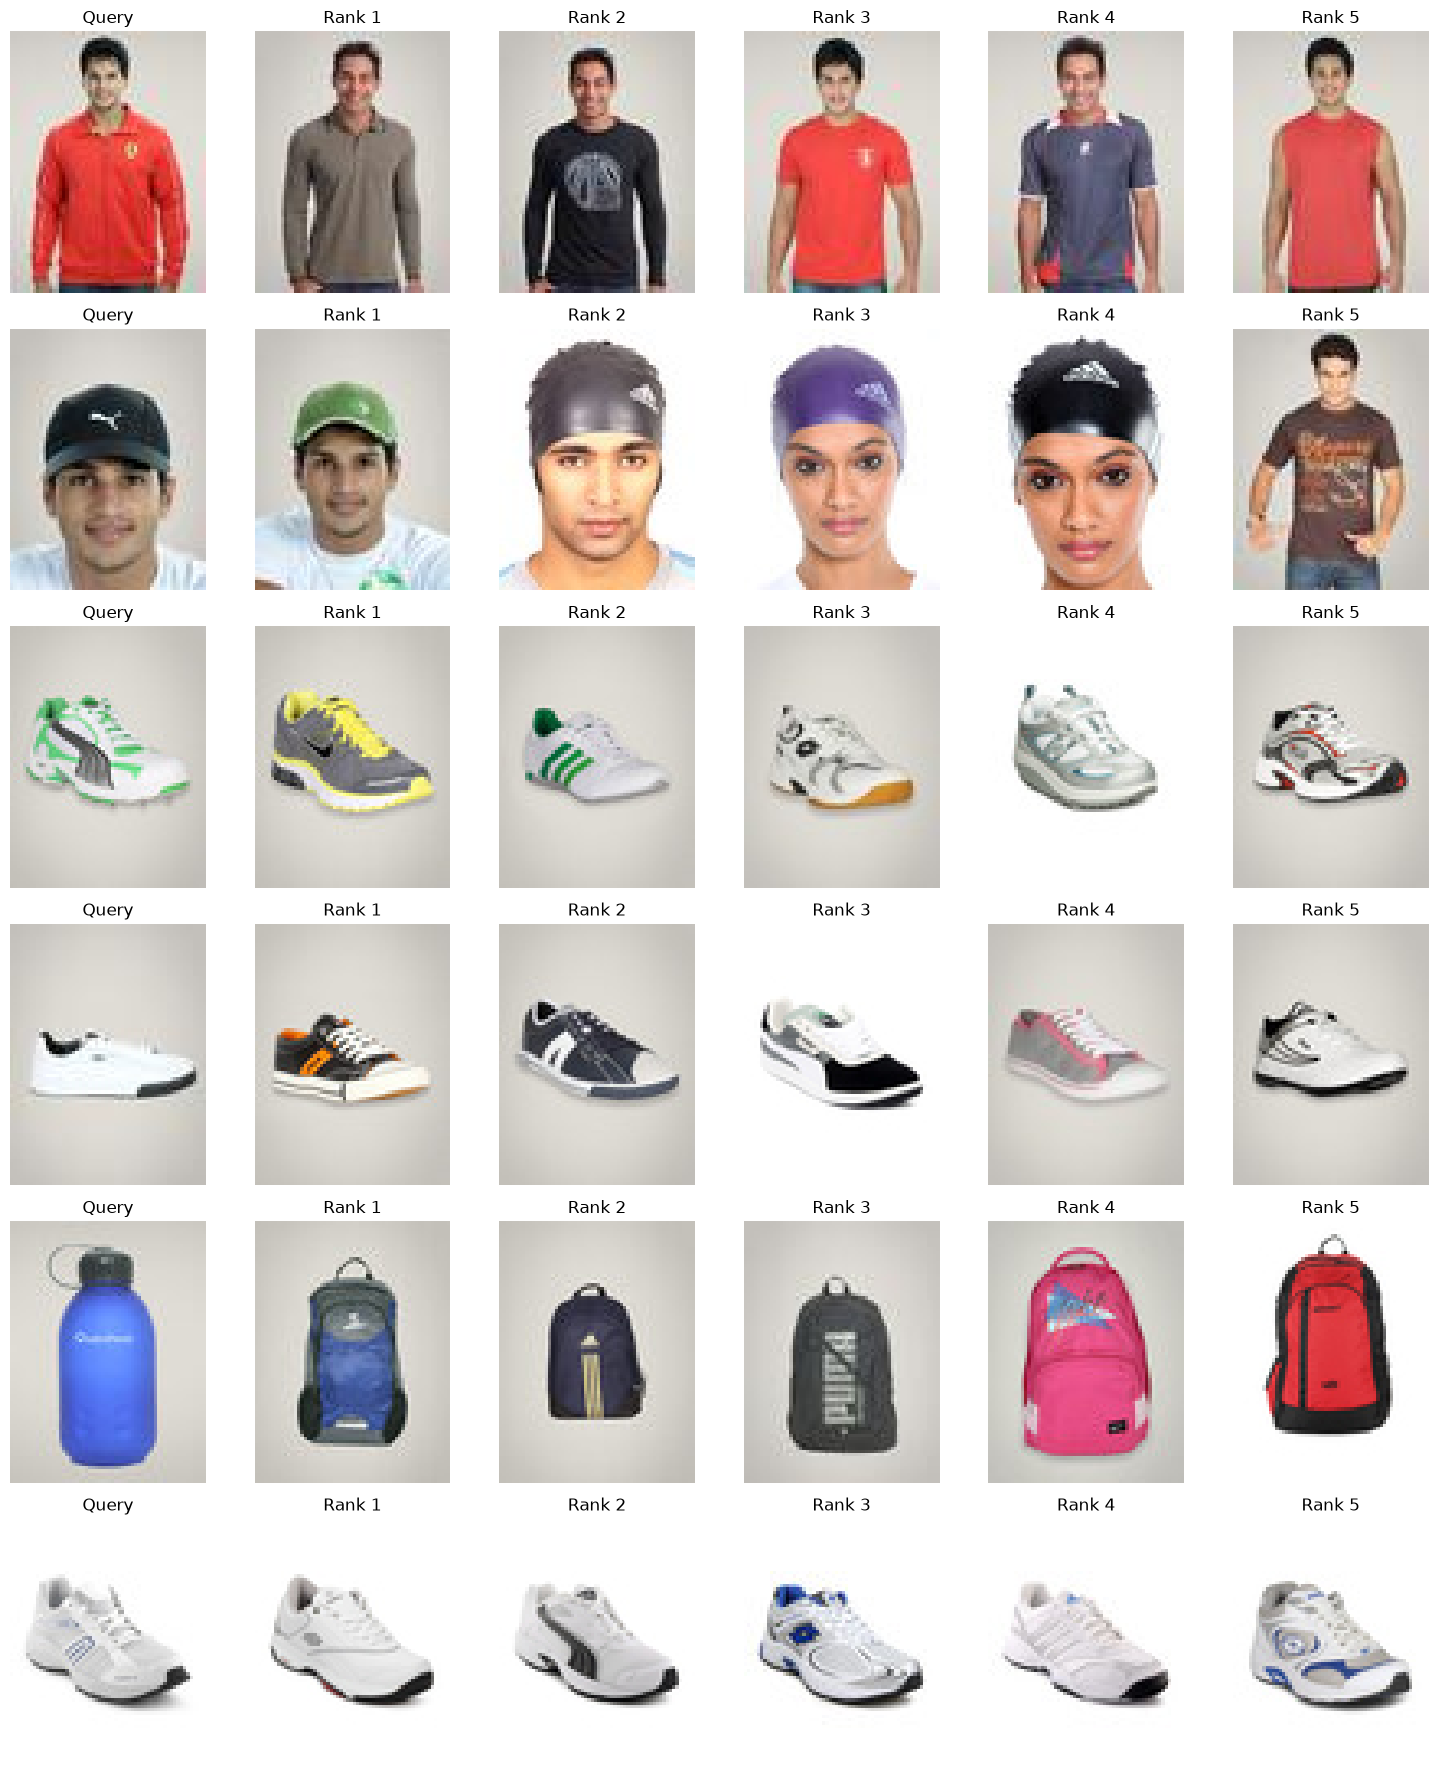

In [11]:
# Display example test queries beside their five nearest training images.
queries = frames['test'].head(6)
fig, axes = plt.subplots(len(queries), 6, figsize=(15, 3 * len(queries)), squeeze=False)
for row, (_, query) in enumerate(queries.iterrows()):

    # Rank the complete training gallery by cosine similarity for this query.
    ranks = np.argsort(-(features['test'][row] @ features['train'].T), kind='stable')[:5]
    paths = [query.image_path] + frames['train'].iloc[ranks].image_path.tolist()
    for column, path in enumerate(paths):
        with Image.open(path) as image:
            axes[row, column].imshow(image.convert('RGB'))
        axes[row, column].axis('off')
        axes[row, column].set_title('Query' if column == 0 else f'Rank {column}')
fig.tight_layout()
plt.show()
plt.close(fig)

## 6. Save the Search Gallery
After evaluation, include all supplied training-release partitions in the deployment gallery. The model hash prevents mismatched embeddings after retraining Task 1. The API additionally prioritizes predicted article type; the metrics above use pure cosine ranking.

In [15]:
# Export the normalized embeddings, aligned metadata, and encoder recipe used by the web application.
gallery = pd.concat(list(frames.values()), ignore_index=True)
embeddings = np.vstack(list(features.values()))
assert not gallery.id.duplicated().any()
model_dir = ROOT / 'models'

# Keep feature rows aligned with metadata rows when exporting the search index.
np.save(model_dir / 'visual_search_embeddings.npy', embeddings)
gallery[['id', 'image_path', 'articleType', 'baseColour', 'gender', 'usage', 'subCategory']].to_csv(
    model_dir / 'visual_search_metadata.csv', index=False
)
config = {
    'model_type': 'keras_embedding_cosine',
    'encoder_file': MODEL.name,
    'encoder_sha256': file_digest(MODEL),
    'encoder_model_type': encoder.metadata['model_type'],
    'embedding_dim': embeddings.shape[1],
    'recipe': 'last_hidden_layer_l2_cosine',
    'evaluation_scope': 'internal_test_with_prior_development_exposure',
}
(model_dir / 'visual_search_model.json').write_text(json.dumps(config, indent=2) + '\n')
print('Exported neural search gallery and configuration.')

Exported neural search gallery and configuration.


## 7. Observations & Discussion

### 7.1. Category retrieval and validation–test consistency

The selected article-type encoder is the weighted-continuation CNN from Task 1. It produces 256-dimensional, L2-normalized hidden-layer vectors without further training. Evaluation uses 27,051 training-gallery images and group-disjoint queries: 5,842 validation and 5,718 internal-test images. These query sets do not contain the same connected product groups as the evaluation gallery.

Article-type precision@1 is 87.30% on validation and 86.15% on test; precision@5 is 85.40% and 84.78%. Thus, a test query returns about 4.24 category-relevant images among its first five results on average. Test hit-rate@5 is 93.86% and hit-rate@10 is 95.40%, so most queries obtain at least one category match even when their first result is wrong. Test mean reciprocal rank is 0.8959. This MRR uses the complete gallery ranking, not only its first ten results.

The 1.15-percentage-point validation–test gap in precision@1 is small descriptively. However, these are image-weighted averages on one fixed dataset, not uncertainty estimates or evidence of external generalization. Common categories contribute more queries than rare categories, and no per-category retrieval table was produced. High overall precision therefore cannot establish reliable retrieval for every article type.

### 7.2. Colour agreement and recall

When relevance requires both article type and baseColour, test precision@1 falls to 29.77%, precision@5 to 26.54% and MRR to 0.4288. On average, only 1.33 of the first five results match both fields. Joint hit-rate@5 is 58.22%, increasing to 69.53% at ten results. Returning more candidates improves the chance of finding one joint match, while precision falls to 24.88% at ten results.

This gap is consistent with an encoder trained for category classification rather than colour-aware similarity. It is not direct proof of which features the network uses, and metadata colour agreement is an imperfect proxy for human perception. Test recall@10 is only 2.17% for article relevance and 3.22% for joint relevance because recall divides by all relevant gallery items, often far more than ten. Higher joint recall does not imply better joint retrieval: the joint criterion has fewer relevant items in its denominator. Queries with no relevant gallery item receive zero recall and reciprocal rank under this implementation.

### 7.3. Qualitative successes and failures

The displayed six queries are the first six test images in dataset order, not selected successes. The shoe queries generally return footwear with similar broad silhouettes, but the green-and-white shoe's first result is grey/yellow, and the white shoe query includes pink and dark alternatives. The red top query retrieves several different colours; a red candidate appears at rank three. These examples illustrate why category agreement can be high while joint colour agreement remains low.

The cap query returns several headwear items but also a shirt image at rank five. More seriously, the blue bottle query retrieves five bags. This is a visible category failure, and shared outline or photographic composition is only a possible explanation; the figure alone cannot establish its cause. Six examples are useful for diagnosis but cannot quantify the prevalence of any failure type or establish a rare-class effect.

### 7.4. Deployment scope and conclusion

After evaluation, the exported deployment gallery contains all 38,611 usable labelled images, with a 38,611 x 256 embedding array. Its configuration records the exact article-type model hash so stale embeddings can be detected after retraining. Evaluation scores refer to pure cosine ranking against the training-only gallery. The application's additional prioritization of predicted article type and its larger gallery were not measured by this experiment, so these scores should not be presented as end-to-end web-search performance.

The representation is useful for category-oriented product discovery but is substantially weaker when colour must also agree. A future experiment could assess explicit colour features or colour-aware training using validation groups and a predefined relevance rule; it should not tune against the reported test scores. Broader style similarity would require human relevance judgments. No additional encoder training or external retrieval benchmark was performed here, and the internal test retains its prior development exposure.

## 8. Compare Final Classification Results

Use the summaries and family-comparison tables produced by the main Tasks 1-3. Historical experimental tuning tables are not required.


### 8.1. Required Libraries

These libraries support the operations below; no training algorithms are imported from project scripts.

In [12]:
# Libraries and labels for displaying the completed main-run results.
import json
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from scripts.preprocessing import ROOT

DIRECTORY = ROOT / 'results'
TASKS = {'article_type': 'Article type', 'season': 'Season',
         'gender': 'Gender', 'usage': 'Occasion'}
FAMILIES = {'shallow_mlp': 'Shallow MLP (baseline)',
            'deeper_mlp': 'Deeper MLP', 'cnn': 'CNN'}

### 8.2. Evaluation Scope

Compare the three model families on the selection half of the frozen validation groups. Selection prioritizes supported-class macro-F1, then accuracy, then parameter count. The CNN row represents the configured CNN run in each main notebook. The submitted classifiers use temperature 1.0 and no automatic review policy. Internal-test results have prior development exposure and are not an untouched independent evaluation.

### 8.3. Read and verify completed classification results

In [13]:
# Read only artifacts generated by the main classification notebooks.
required = [DIRECTORY / f'{task}_{suffix}' for task in TASKS
            for suffix in ('summary.json', 'comparison.csv')]
missing = [path.name for path in required if not path.is_file()]
if missing:
    raise FileNotFoundError(f'Missing main classification outputs: {missing}')
summaries = {task: json.loads((DIRECTORY / f'{task}_summary.json').read_text())
             for task in TASKS}
comparisons = {task: pd.read_csv(DIRECTORY / f'{task}_comparison.csv')
              for task in TASKS}
for task, frame in comparisons.items():
    if summaries[task]['framework'] != 'tensorflow_keras':
        raise ValueError(f'{task}: expected Keras results')
    if set(frame.family) != set(FAMILIES) or len(frame) != 3:
        raise ValueError(f'{task}: expected one result per model family')
    ranked = frame.sort_values(
        ['validation_macro_f1', 'validation_accuracy', 'complexity_parameters'],
        ascending=[False, False, True])
    if ranked.iloc[0, 0] != summaries[task]['selected']:
        raise ValueError(f'{task}: summary and comparison winner disagree')
comparisons = {task: frame.set_index('family') for task, frame in comparisons.items()}

### 8.4. Plot the three-family comparison

Show selection accuracy beside supported-class macro-F1. These metrics come from the main-run comparison tables; internal-test results do not determine the model ranking.


,Article type,Season,Gender,Occasion
Model,,,,
Shallow MLP (baseline),0.7421,0.6997,0.8469,0.8738
Deeper MLP,0.7324,0.6869,0.8452,0.8562
CNN,0.8697,0.7578,0.8993,0.8945


,Article type,Season,Gender,Occasion
Model,,,,
Shallow MLP (baseline),0.4432,0.6579,0.7118,0.4522
Deeper MLP,0.3783,0.6458,0.6912,0.3600
CNN,0.6964,0.7394,0.7901,0.4543


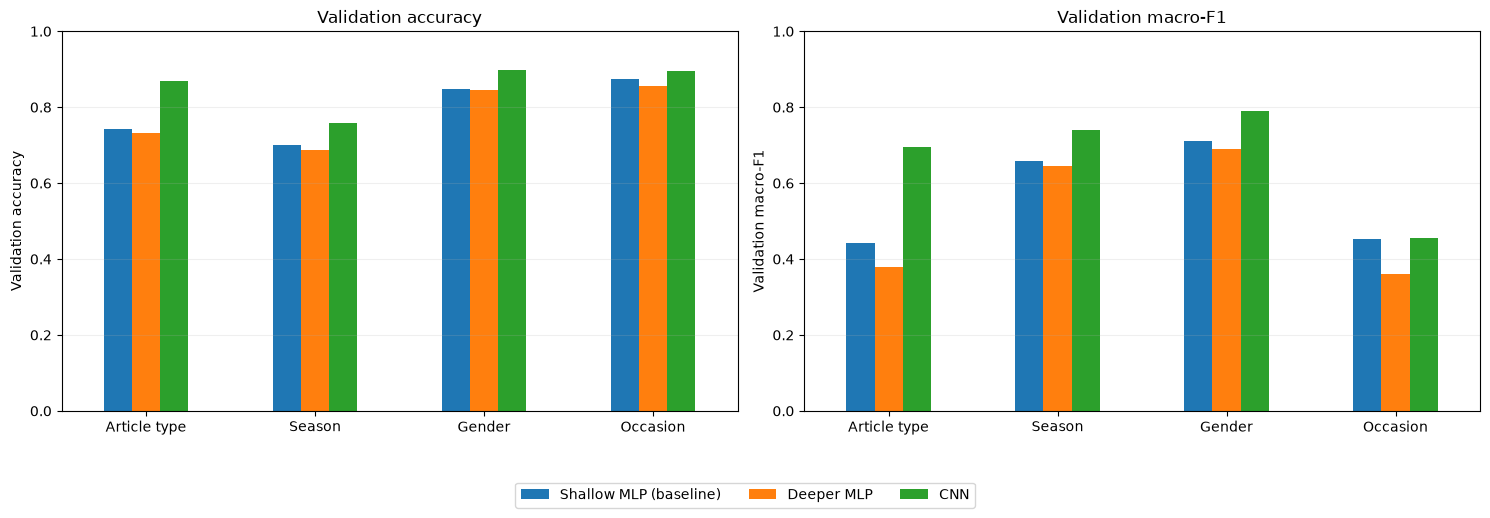

In [3]:
# Display the main-run selection metrics and their comparison plot.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Create one cross-target table and bar chart for each selection metric.
for axis, metric, title in zip(
    axes,
    ['validation_accuracy', 'validation_macro_f1'],
    ['Validation accuracy', 'Validation macro-F1'],
):
    table = pd.DataFrame(
        {
            TASKS[task]: frame.loc[list(FAMILIES), metric].to_numpy()
            for task, frame in comparisons.items()
        },
        index=list(FAMILIES.values()),
    )
    display(table.rename_axis('Model').round(4))
    table.T.plot.bar(ax=axis, rot=0, ylim=(0, 1), title=title, legend=False)
    axis.set_ylabel(title)
    axis.grid(axis='y', alpha=0.2)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.04))
fig.tight_layout(rect=(0, 0.09, 1, 1))
plt.show()
plt.close(fig)


## 9. Final Prediction

Load the four selected classifiers exported by Tasks 1-3 and predict the supplied test images. This is classification submission generation, separate from visual-search evaluation. It does not fit models or use course-test labels. The CSV preserves the template columns and original ID order.

### 9.1. Load the Template and Selected Models

In [20]:
# Load the required submission rows and all four selected classifiers.
from scripts.preprocessing import load_prediction_template

submission_template = load_prediction_template()
submission_columns = [column for column in submission_template.columns if column != 'image_path']

# Map each required output column to its selected Keras classifier.
submission_model_paths = {
    'articleType': ROOT / 'models/article_type_model.keras',
    'season': ROOT / 'models/season_model.keras',
    'gender': ROOT / 'models/gender_model.keras',
    'usage': ROOT / 'models/usage_model.keras',
}
submission_checkpoints = {
    target: load_checkpoint(path) for target, path in submission_model_paths.items()
}
if set(submission_columns) != {'id', *submission_model_paths}:
    raise ValueError('Unexpected prediction-template columns')
for target, checkpoint in submission_checkpoints.items():
    if checkpoint['target'] != target:
        raise ValueError(f'Wrong target in selected model: {target}')
display(submission_template.head())

,id,gender,articleType,season,usage,image_path
0,52003,,,,,/mnt/d/khoile/programs/fashion-intelligence-cl...
1,52007,,,,,/mnt/d/khoile/programs/fashion-intelligence-cl...
2,52017,,,,,/mnt/d/khoile/programs/fashion-intelligence-cl...
3,52021,,,,,/mnt/d/khoile/programs/fashion-intelligence-cl...
4,52023,,,,,/mnt/d/khoile/programs/fashion-intelligence-cl...


### 9.2. Predict Course-Test Images

Apply each model's saved normalization and label order. The highest logit gives the predicted label; softmax and positive temperature scaling preserve this argmax, so confidence calibration does not change the submission labels. Training-only augmentation is disabled with `training=False`.

In [21]:
# Predict every required label for each test image while decoding that image only once.
submission_rows = []

# Open each image once, then run the four target-specific classifiers.
for position, row in enumerate(submission_template.itertuples(index=False), start=1):
    predictions = {}
    with Image.open(row.image_path) as image:
        for target, checkpoint in submission_checkpoints.items():
            inputs = image_batch(
                image, checkpoint['image_size'], checkpoint['mean'], checkpoint['std']
            )
            logits = np.asarray(checkpoint['model'](inputs, training=False))[0]
            if not np.isfinite(logits).all():
                raise ValueError(f'Non-finite prediction for image {row.id}, target {target}')
            predictions[target] = checkpoint['labels'][int(logits.argmax())]
    submission_rows.append({'id': row.id, **predictions})
    if position % 500 == 0:
        print(f'Predicted {position:,}/{len(submission_template):,} images')
submission = pd.DataFrame(submission_rows, columns=submission_columns)
display(submission.head())

Predicted 500/5,829 images


Predicted 1,000/5,829 images


Predicted 1,500/5,829 images


Predicted 2,000/5,829 images


Predicted 2,500/5,829 images


...

Predicted 4,000/5,829 images


Predicted 4,500/5,829 images


Predicted 5,000/5,829 images


Predicted 5,500/5,829 images


,id,gender,articleType,season,usage
0,52003,Men,Tops,Fall,Casual
1,52007,Women,Dresses,Summer,Casual
2,52017,Men,Sports Shoes,Summer,Casual
3,52021,Women,Nightdress,Summer,Casual
4,52023,Men,Tshirts,Summer,Casual


### 9.3. Validate and Save the CSV

In [22]:
# Validate IDs, ordering, completeness, and label vocabularies before writing the submission.
if submission.empty:
    raise ValueError('The prediction template is empty')
if submission['id'].tolist() != submission_template['id'].tolist():
    raise ValueError('Prediction IDs or order differ from the template')
if submission['id'].duplicated().any():
    raise ValueError('Submission contains duplicate IDs')

# Check prediction completeness separately from ID integrity.
values = submission.drop(columns='id')
if values.isna().any().any() or values.eq('').any().any():
    raise ValueError('Submission contains missing predictions')
for target, checkpoint in submission_checkpoints.items():
    if not set(submission[target]).issubset(checkpoint['labels']):
        raise ValueError(f'Unknown label in {target} predictions')
submission_path = ROOT / 'prediction/styles_prediction.csv'
submission_path.parent.mkdir(parents=True, exist_ok=True)
submission.to_csv(submission_path, index=False)
print(f'Saved {len(submission):,} predictions to {submission_path}')

Saved 5,829 predictions to /mnt/d/khoile/programs/fashion-intelligence-classification/prediction/styles_prediction.csv
